In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/home/davian/Projects/ML-Template/clasificacion/data/breast-cancer.csv')

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [3]:
from preprocessing.split_data import dividir_datos
from src.config import TARGET

x_train, x_test, y_train, y_test = dividir_datos(df, target=TARGET)

In [4]:
from preprocessing.pipeline import estandarizar, codificar

x_train_prep, x_test_prep, _ = estandarizar(x_train, x_test)

y_train_prep, y_test_prep, _ = codificar(y_train, y_test)

In [5]:
from sklearn.ensemble import RandomForestClassifier

tree_model = RandomForestClassifier()

tree_model.fit(x_train_prep, y_train_prep)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
tree_model.feature_importances_

array([0.00430111, 0.06672291, 0.01337803, 0.05541696, 0.06629803,
       0.00821756, 0.01731004, 0.03044039, 0.09769178, 0.00462814,
       0.0023091 , 0.01542122, 0.00567915, 0.01547065, 0.03159588,
       0.00327528, 0.00573528, 0.00492644, 0.002455  , 0.0027739 ,
       0.00680594, 0.1066264 , 0.02065935, 0.13734424, 0.10516076,
       0.01684756, 0.0244556 , 0.03272152, 0.07555878, 0.01393148,
       0.00584151])

In [ ]:
imp_df = pd.DataFrame({
    'feature': list(x_train), 
    'importance': tree_model.feature_importances_
    }).sort_values(by='importance',ascending=False)

In [ ]:
imp_df

,feature,importance
23,perimeter_worst,0.137344
21,radius_worst,0.106626
24,area_worst,0.105161
8,concave points_mean,0.097692
28,concave points_worst,0.075559
1,radius_mean,0.066723
4,area_mean,0.066298
3,perimeter_mean,0.055417
27,concavity_worst,0.032722
14,area_se,0.031596


<Axes: xlabel='importance', ylabel='feature'>

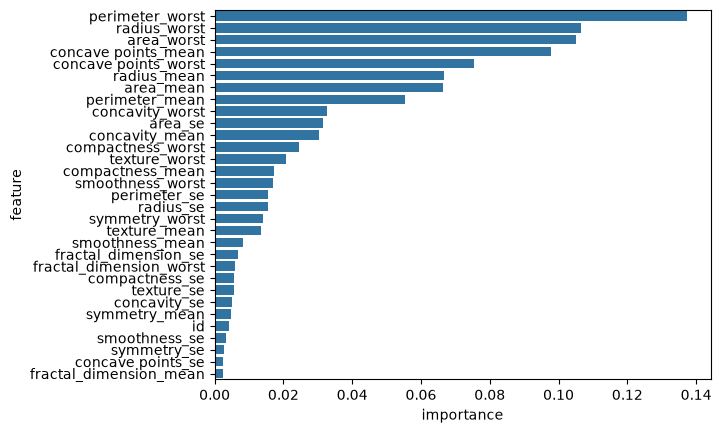

In [ ]:
sns.barplot(data=imp_df, x='importance', y='feature')

In [ ]:
imp_df['feature'][:11]

23         perimeter_worst
21            radius_worst
24              area_worst
8      concave points_mean
28    concave points_worst
1              radius_mean
4                area_mean
3           perimeter_mean
27         concavity_worst
14                 area_se
7           concavity_mean
Name: feature, dtype: str